# Codebook Utilization Analysis

This notebook analyzes the codebook utilization patterns of RQ-VAE models for job semantic ID generation.

## Overview
- Visualize codebook usage across different levels
- Analyze utilization efficiency
- Compare different model configurations
- Identify underutilized or overutilized codebooks

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Set figure size defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Configuration

Set the global parameters for your model configuration. Modify these values to analyze different models.

In [2]:
# Global Configuration Parameters
# Modify these values to analyze different model configurations

# Model Configuration
LEVELS = 3  # Number of semantic ID levels
CODEBOOK_SIZE = 256  # Size of each codebook

# Data Configuration
DATA_PATH = "../../data/output/jobs_semantic_ids_L3_C256_collision_resolved.parquet"  # Path to your data file

# Analysis Configuration
TITLE_SUFFIX = f"(L{LEVELS}_C{CODEBOOK_SIZE})"  # Suffix for plot titles

print(f"Configuration:")
print(f"  Levels: {LEVELS}")
print(f"  Codebook Size: {CODEBOOK_SIZE}")
print(f"  Data Path: {DATA_PATH}")
print(f"  Title Suffix: {TITLE_SUFFIX}")

Configuration:
  Levels: 3
  Codebook Size: 256
  Data Path: ../../data/output/jobs_semantic_ids_L3_C256_collision_resolved.parquet
  Title Suffix: (L3_C256)


## Utility Functions

In [3]:
def plot_codebook_utilization(df, levels=None, codebook_size=None, title_suffix=None):
    """
    Plot codebook utilization for each level of semantic IDs
    
    Args:
        df: DataFrame with semantic_id_level_0, semantic_id_level_1, etc. columns
        levels: Number of semantic ID levels (uses global LEVELS if None)
        codebook_size: Size of each codebook (uses global CODEBOOK_SIZE if None)
        title_suffix: Additional text for plot titles (uses global TITLE_SUFFIX if None)
    """
    # Use global values if not provided
    levels = levels or LEVELS
    codebook_size = codebook_size or CODEBOOK_SIZE
    title_suffix = title_suffix or TITLE_SUFFIX
    
    # Create figure with vertically stacked subplots
    fig, axes = plt.subplots(levels, 1, figsize=(20, 4*levels))
    if levels == 1:
        axes = [axes]
    
    # Colors for each level
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    
    # Plot histogram for each semantic ID level
    for level in range(levels):
        col_name = f"semantic_id_level_{level}"
        if col_name not in df.columns:
            continue
            
        values = df[col_name].to_list()
        
        axes[level].hist(values, bins=codebook_size, range=(0, codebook_size-1), 
                        edgecolor="black", alpha=0.7, color=colors[level])
        axes[level].set_xlabel(f"Semantic ID Level {level} Value", fontsize=12)
        axes[level].set_xlim(0, codebook_size-1)
        axes[level].set_ylabel("Count", fontsize=12)
        axes[level].set_title(f"Distribution of Codebook Usage Level {level} {title_suffix}", fontsize=14)
        axes[level].grid(True, alpha=0.3)
        
        # Add statistics text
        mean_val = np.mean(values)
        std_val = np.std(values)
        unique_count = df[col_name].n_unique()
        
        axes[level].text(
            0.02, 0.98,
            f"Unique: {unique_count}/{codebook_size}\nMean: {mean_val:.1f}\nStd: {std_val:.1f}",
            transform=axes[level].transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
            fontsize=11,
        )
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("Codebook Utilization Statistics:")
    print("=" * 40)
    for level in range(levels):
        col_name = f"semantic_id_level_{level}"
        if col_name not in df.columns:
            continue
            
        values = df[col_name].to_list()
        unique_count = df[col_name].n_unique()
        
        print(f"\nLevel {level}:")
        print(f"  Unique values used: {unique_count}/{codebook_size} ({unique_count/codebook_size*100:.1f}%)")
        print(f"  Mean: {np.mean(values):.2f}")
        print(f"  Std: {np.std(values):.2f}")
        
        # Get bin counts for usage analysis
        bin_counts = np.bincount(values, minlength=codebook_size)
        used_codes = bin_counts[bin_counts > 0]
        if len(used_codes) > 0:
            print(f"  Min usage: {min(used_codes)}")
            print(f"  Max usage: {max(used_codes)}")
        print(f"  Unused codes: {codebook_size - unique_count}")

In [4]:
def plot_codebook_comparison(df, levels=None, codebook_size=None, title_suffix=None):
    """
    Plot overlaid histograms to compare codebook usage across levels
    """
    # Use global values if not provided
    levels = levels or LEVELS
    codebook_size = codebook_size or CODEBOOK_SIZE
    title_suffix = title_suffix or TITLE_SUFFIX
    
    plt.figure(figsize=(20, 6))
    
    for level in range(levels):
        col_name = f"semantic_id_level_{level}"
        if col_name not in df.columns:
            continue
            
        values = df[col_name].to_list()
        plt.hist(values, bins=codebook_size, range=(0, codebook_size-1), 
                alpha=0.5, label=f"Level {level}", edgecolor="none")
    
    plt.xlabel("Semantic ID Value")
    plt.xlim(0, codebook_size-1)
    plt.ylabel("Count")
    plt.title(f"Distribution of Semantic IDs Across All Levels (Overlaid) {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [5]:
def analyze_codebook_efficiency(df, levels=None, codebook_size=None):
    """
    Analyze codebook efficiency and utilization patterns
    """
    # Use global values if not provided
    levels = levels or LEVELS
    codebook_size = codebook_size or CODEBOOK_SIZE
    
    print("Codebook Efficiency Analysis:")
    print("=" * 50)
    
    total_capacity = codebook_size ** levels
    total_items = len(df)
    utilization_ratio = total_items / total_capacity
    
    print(f"Total capacity: {total_capacity:,}")
    print(f"Total items: {total_items:,}")
    print(f"Utilization ratio: {utilization_ratio:.4f}")
    print()
    
    for level in range(levels):
        col_name = f"semantic_id_level_{level}"
        if col_name not in df.columns:
            continue
            
        values = df[col_name].to_list()
        unique_count = df[col_name].n_unique()
        usage_rate = unique_count / codebook_size
        
        print(f"Level {level}:")
        print(f"  Usage rate: {usage_rate:.1%}")
        print(f"  Efficiency: {'High' if usage_rate > 0.8 else 'Medium' if usage_rate > 0.5 else 'Low'}")
        print()

## Load Data

Load the semantic ID data for analysis

In [6]:
# Load the data using the configured path
df = pl.read_parquet(DATA_PATH)

print(f"Loaded data with {len(df)} rows")
print(f"Columns: {df.columns}")
print(f"\nFirst few rows:")
print(df.head())

Loaded data with 308353 rows
Columns: ['parent_asin', 'semantic_id_level_0', 'semantic_id_level_1', 'semantic_id_level_2', 'semantic_id_level_3', 'semantic_id', 'codebook_levels', 'codebook_size', 'embedding_dim', 'collision_resolved']

First few rows:
shape: (5, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ parent_as ┆ semantic_ ┆ semantic_ ┆ semantic_ ┆ … ┆ codebook_ ┆ codebook_ ┆ embedding ┆ collisio │
│ in        ┆ id_level_ ┆ id_level_ ┆ id_level_ ┆   ┆ levels    ┆ size      ┆ _dim      ┆ n_resolv │
│ ---       ┆ 0         ┆ 1         ┆ 2         ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ed       │
│ i64       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ i64       ┆ i64       ┆ i64       ┆ ---      │
│           ┆ i64       ┆ i64       ┆ i64       ┆   ┆           ┆           ┆           ┆ bool     │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 8703      ┆ 9         ┆

## Basic Codebook Utilization Analysis

Analyze how well the model utilizes its codebook capacity

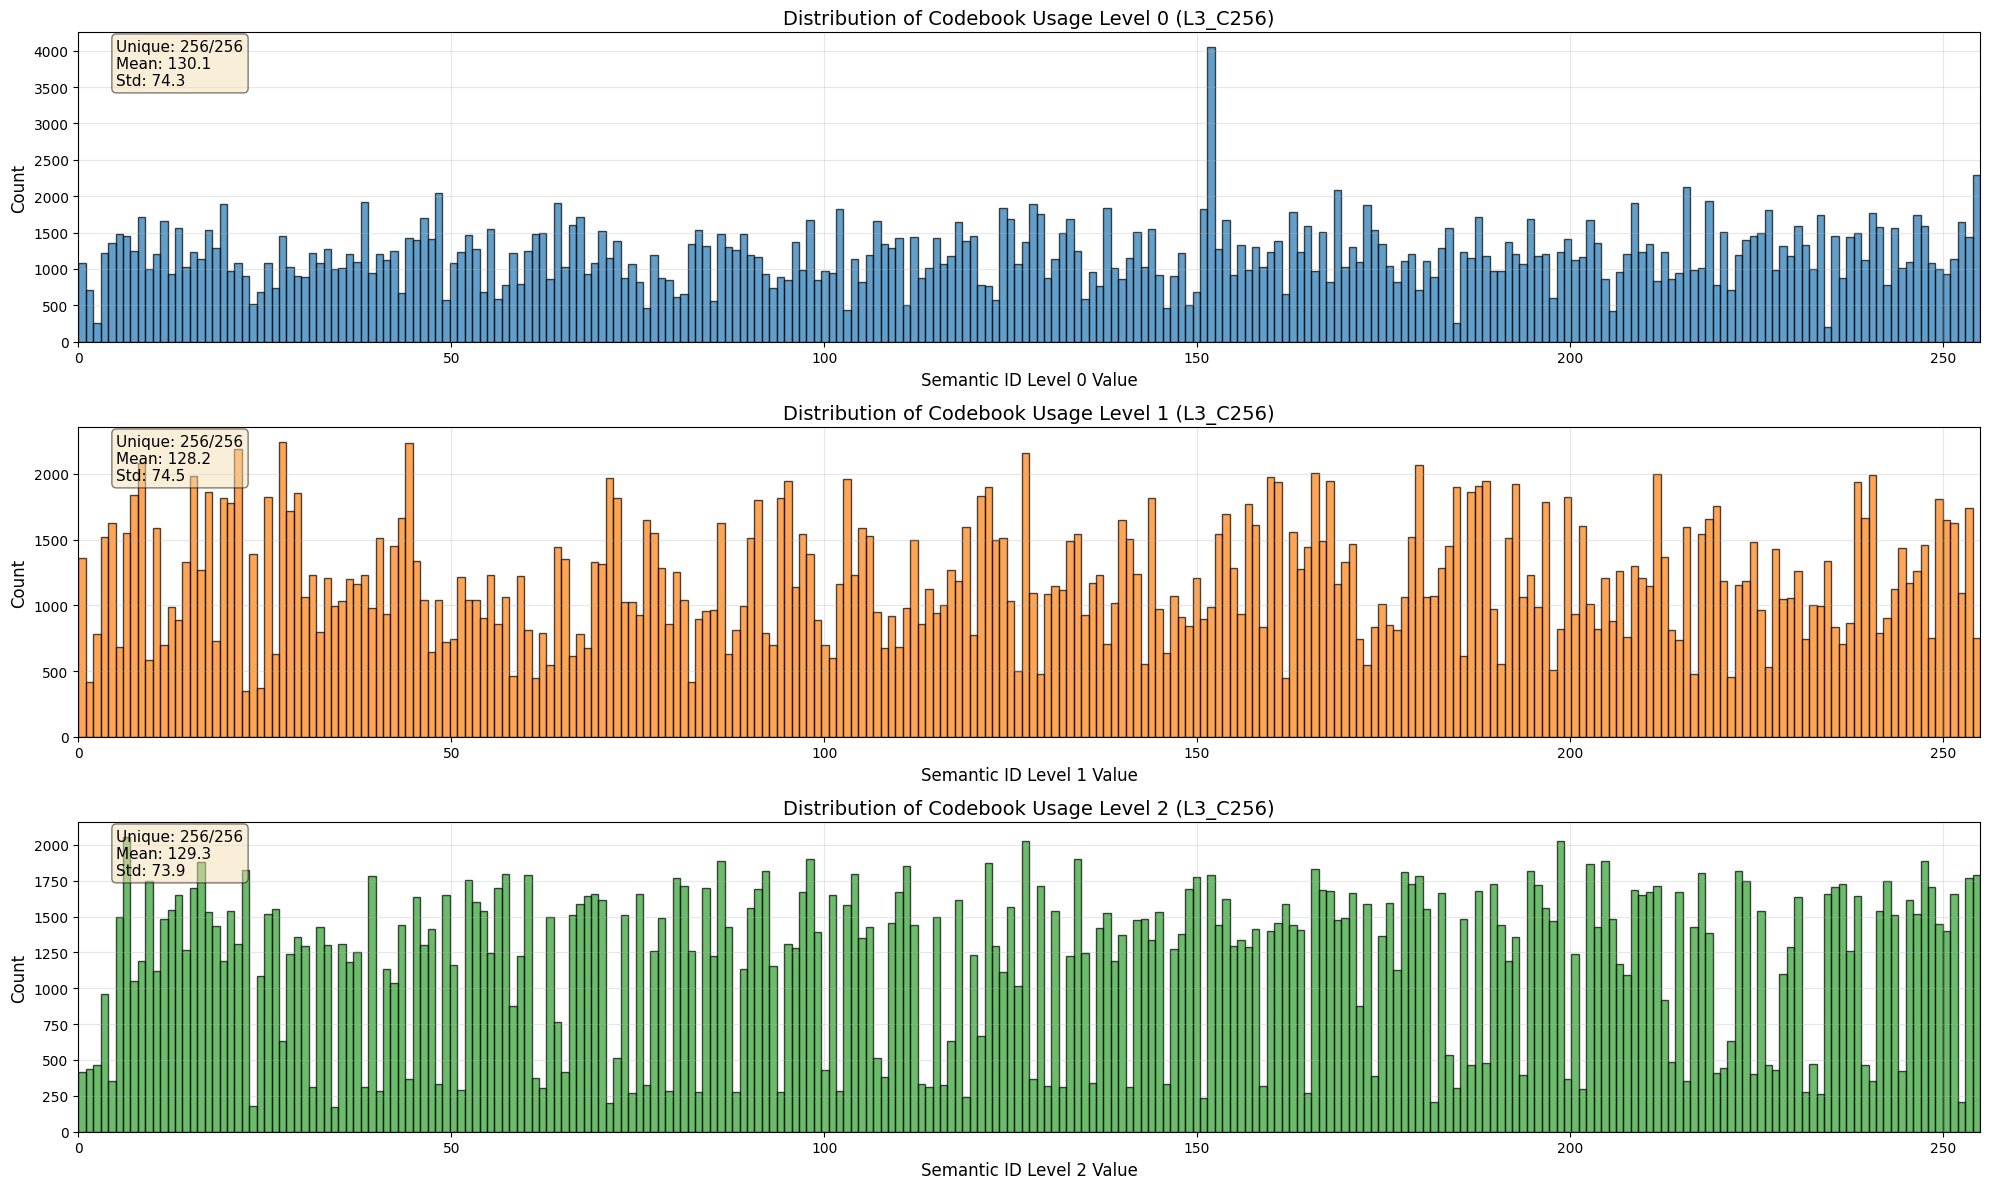

Codebook Utilization Statistics:

Level 0:
  Unique values used: 256/256 (100.0%)
  Mean: 130.14
  Std: 74.30
  Min usage: 200
  Max usage: 4050
  Unused codes: 0

Level 1:
  Unique values used: 256/256 (100.0%)
  Mean: 128.17
  Std: 74.45
  Min usage: 350
  Max usage: 2242
  Unused codes: 0

Level 2:
  Unique values used: 256/256 (100.0%)
  Mean: 129.29
  Std: 73.93
  Min usage: 170
  Max usage: 2054
  Unused codes: 0


In [7]:
# Plot codebook utilization using global configuration
plot_codebook_utilization(df, codebook_size=CODEBOOK_SIZE, title_suffix=TITLE_SUFFIX, levels=LEVELS)

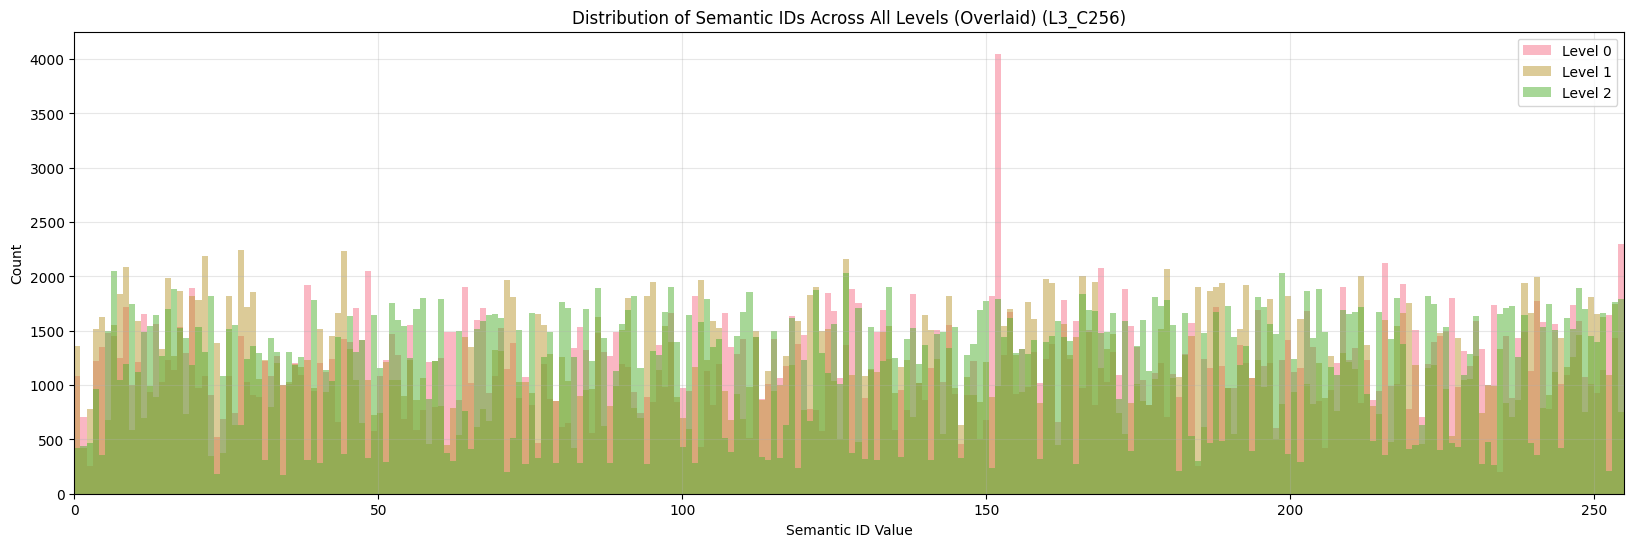

In [8]:
# Plot overlaid comparison using global configuration
plot_codebook_comparison(df, codebook_size=CODEBOOK_SIZE, title_suffix=TITLE_SUFFIX, levels=LEVELS)

In [9]:
# Analyze efficiency using global configuration
analyze_codebook_efficiency(df, codebook_size=CODEBOOK_SIZE, levels=LEVELS)

Codebook Efficiency Analysis:
Total capacity: 16,777,216
Total items: 308,353
Utilization ratio: 0.0184

Level 0:
  Usage rate: 100.0%
  Efficiency: High

Level 1:
  Usage rate: 100.0%
  Efficiency: High

Level 2:
  Usage rate: 100.0%
  Efficiency: High



## Collision Analysis

Analyze collision patterns and resolution effectiveness

Items with collision resolution: 308353/308353 (100.0%)
Collision resolution codes used: 43


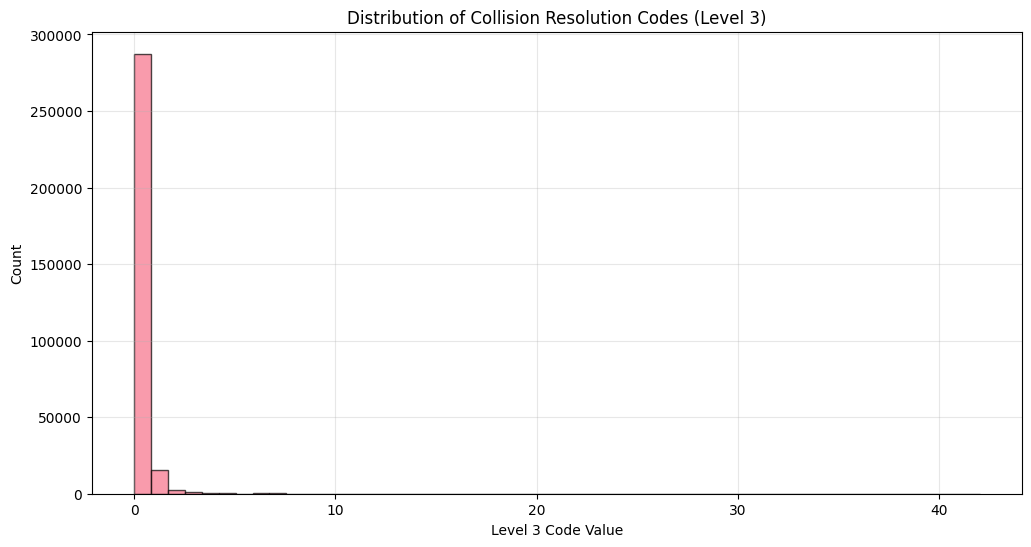

In [10]:
# Check collision resolution
if 'collision_resolved' in df.columns:
    collision_count = df['collision_resolved'].sum()
    total_items = len(df)
    print(f"Items with collision resolution: {collision_count}/{total_items} ({collision_count/total_items*100:.1f}%)")
    
    # Check if collision resolution level exists
    collision_level = LEVELS  # Collision resolution is typically at the next level
    collision_col = f"semantic_id_level_{collision_level}"
    
    if collision_col in df.columns:
        collision_usage = df[collision_col].n_unique()
        print(f"Collision resolution codes used: {collision_usage}")
        
        # Plot collision resolution usage
        plt.figure(figsize=(12, 6))
        collision_values = df[collision_col].to_list()
        plt.hist(collision_values, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel(f'Level {collision_level} Code Value')
        plt.ylabel('Count')
        plt.title(f'Distribution of Collision Resolution Codes (Level {collision_level})')
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("No collision resolution data found")

## Cluster Analysis

Analyze clustering patterns and semantic ID distribution

Unique semantic ID combinations: 287,418
Total items: 308,353
Collision rate: 6.79%


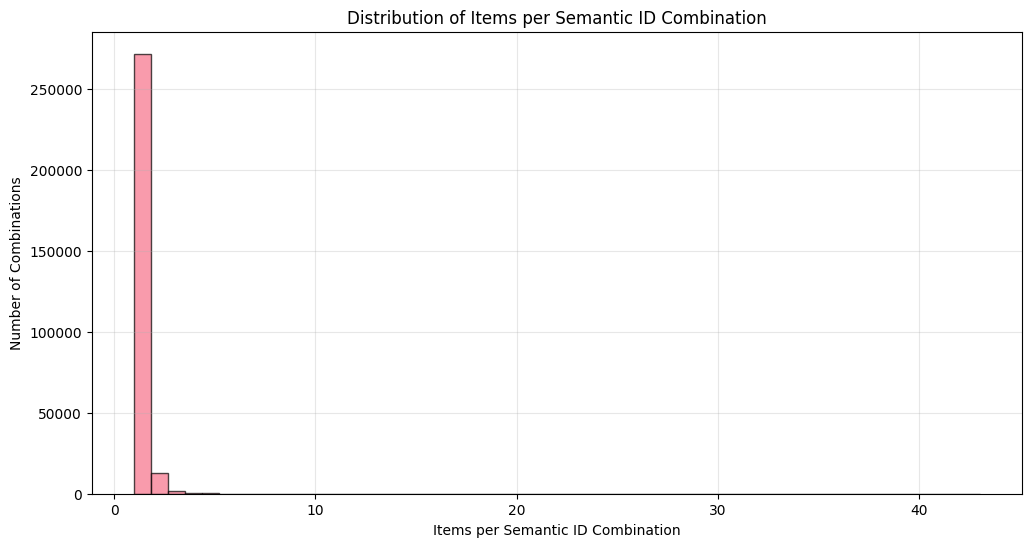


Top 10 most collided combinations:
shape: (10, 2)
┌───────────────────┬───────┐
│ semantic_id_combo ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ 152_91_16         ┆ 43    │
│ 6_136_80          ┆ 34    │
│ 152_105_236       ┆ 30    │
│ 152_105_199       ┆ 30    │
│ 86_241_6          ┆ 28    │
│ 91_97_57          ┆ 26    │
│ 69_134_252        ┆ 26    │
│ 152_21_122        ┆ 24    │
│ 152_157_9         ┆ 22    │
│ 152_21_179        ┆ 22    │
└───────────────────┴───────┘


In [11]:
# Analyze unique semantic ID combinations
level_cols = [f"semantic_id_level_{i}" for i in range(LEVELS)]
if all(col in df.columns for col in level_cols):
    # Create semantic ID combination
    combo_expr = pl.col(level_cols[0]).cast(str)
    for col in level_cols[1:]:
        combo_expr = combo_expr + "_" + pl.col(col).cast(str)
    
    df_with_combo = df.with_columns(
        combo_expr.alias('semantic_id_combo')
    )
    
    unique_combos = df_with_combo['semantic_id_combo'].n_unique()
    total_items = len(df_with_combo)
    
    print(f"Unique semantic ID combinations: {unique_combos:,}")
    print(f"Total items: {total_items:,}")
    print(f"Collision rate: {(total_items - unique_combos) / total_items * 100:.2f}%")
    
    # Show collision distribution
    collision_counts = df_with_combo.group_by('semantic_id_combo').agg(pl.len().alias('count'))
    
    plt.figure(figsize=(12, 6))
    plt.hist(collision_counts['count'].to_list(), bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Items per Semantic ID Combination')
    plt.ylabel('Number of Combinations')
    plt.title('Distribution of Items per Semantic ID Combination')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Show top collisions
    top_collisions = collision_counts.sort('count', descending=True).head(10)
    print("\nTop 10 most collided combinations:")
    print(top_collisions)
else:
    print(f"Required columns not found: {level_cols}")

## Model Configuration Analysis

Compare different model configurations and their efficiency

In [12]:
# Extract model configuration from data or use global values
if 'codebook_levels' in df.columns and 'codebook_size' in df.columns:
    data_levels = df['codebook_levels'][0]
    data_codebook_size = df['codebook_size'][0]
    
    print(f"Model Configuration (from data):")
    print(f"  Levels: {data_levels}")
    print(f"  Codebook Size: {data_codebook_size}")
    print(f"  Total Capacity: {data_codebook_size**data_levels:,}")
    print(f"  Items: {len(df):,}")
    print(f"  Utilization: {len(df)/(data_codebook_size**data_levels)*100:.4f}%")
    
    # Check if data config matches global config
    if data_levels != LEVELS or data_codebook_size != CODEBOOK_SIZE:
        print(f"\n⚠️  Warning: Data configuration ({data_levels}, {data_codebook_size}) doesn't match global config ({LEVELS}, {CODEBOOK_SIZE})")
        print(f"Using data configuration for analysis...")
        
        # Update global values to match data
        LEVELS = data_levels
        CODEBOOK_SIZE = data_codebook_size
        TITLE_SUFFIX = f"(L{LEVELS}_C{CODEBOOK_SIZE})"
        
        print(f"Updated global configuration to match data:")
        print(f"  LEVELS = {LEVELS}")
        print(f"  CODEBOOK_SIZE = {CODEBOOK_SIZE}")
        print(f"  TITLE_SUFFIX = {TITLE_SUFFIX}")
else:
    print(f"Model Configuration (from global config):")
    print(f"  Levels: {LEVELS}")
    print(f"  Codebook Size: {CODEBOOK_SIZE}")
    print(f"  Total Capacity: {CODEBOOK_SIZE**LEVELS:,}")
    print(f"  Items: {len(df):,}")
    print(f"  Utilization: {len(df)/(CODEBOOK_SIZE**LEVELS)*100:.4f}%")

# Efficiency assessment
utilization = len(df)/(CODEBOOK_SIZE**LEVELS)
if utilization > 0.1:
    efficiency = "High"
elif utilization > 0.01:
    efficiency = "Medium"
else:
    efficiency = "Low"

print(f"  Efficiency: {efficiency}")

# Recommendations
print(f"\nRecommendations:")
if utilization < 0.01:
    print(f"  - Model is overcapacity (utilization < 1%)")
    print(f"  - Consider smaller model: L{LEVELS-1}_C{int(CODEBOOK_SIZE/2)} or L{LEVELS}_C{int(CODEBOOK_SIZE/4)}")
elif utilization > 0.5:
    print(f"  - Model may be undercapacity (utilization > 50%)")
    print(f"  - Consider larger model: L{LEVELS+1}_C{CODEBOOK_SIZE} or L{LEVELS}_C{CODEBOOK_SIZE*2}")
else:
    print(f"  - Model capacity is well-balanced")

Model Configuration (from data):
  Levels: 3
  Codebook Size: 256
  Total Capacity: 16,777,216
  Items: 308,353
  Utilization: 1.8379%
  Efficiency: Medium

Recommendations:
  - Model capacity is well-balanced


## Summary and Conclusions

Based on the analysis above, we can draw conclusions about:

1. **Codebook Utilization**: How well each level uses its available codes
2. **Model Efficiency**: Whether the model capacity matches the dataset size
3. **Collision Patterns**: How often collisions occur and how well they're resolved
4. **Clustering Quality**: Whether semantic IDs create meaningful clusters

### Key Metrics to Monitor:
- **Usage Rate**: Percentage of codes used in each level
- **Utilization Ratio**: Dataset size vs. total model capacity
- **Collision Rate**: Percentage of items that needed collision resolution
- **Distribution Uniformity**: How evenly codes are distributed

### Optimization Recommendations:
- **High utilization (>80%)**: Model may be undercapacity
- **Low utilization (<10%)**: Model is overcapacity, consider smaller size
- **High collision rate**: May indicate insufficient model capacity
- **Uneven distribution**: May indicate training issues or data imbalance

### How to Use This Notebook:
1. **Modify the Configuration section** to set your model parameters
2. **Update the DATA_PATH** to point to your semantic ID data file
3. **Run all cells** to get a complete analysis
4. **Compare different configurations** by changing the global variables and re-running